# Rn-222 activity-normalized detector response

This notebook converts the repeated Rn-222 simulation outputs from arbitrary simulated-event normalization into expected detector counts for a configurable real Rn-222 source activity. The time cuts are cumulative: `time_s <= T`.


In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display
from pathlib import Path

pd.set_option('display.max_colwidth', None)

figure_output_dir = Path('figures') / 'Detector_performance_analysis_Rn222_activity_normalized'
figure_output_dir.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name):
    """Save a Matplotlib figure as a PNG in this notebook's figures folder."""
    safe_name = ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in str(name)).strip('_')
    path = figure_output_dir / f'{safe_name}.png'
    fig.savefig(path, dpi=200, bbox_inches='tight')
    print(f'Saved figure: {path}')
    return path


## Activity model

The simulation is interpreted as sampling `N_simulated_events` initial Rn-222 atoms/decays. A real source with initial activity `A0` contains `N_atoms = A0 / lambda`, where `lambda = ln(2) / half_life`. Each simulated event therefore represents `N_atoms / N_simulated_events` real atoms. For cumulative cuts, the simulation timing `time_s <= T` selects the fraction of the decay chain observed before `T`.


In [80]:
# Rn-222 source activity configuration
# Change these values to match the source strength you want to show.

rn222_half_life_days = 3.8235
source_activity_uCi = 3.0  # DaRT-like reference activity
source_activity_Bq = source_activity_uCi * 3.7e4
source_area_cm2 = 4.0       # optional, used only for reporting Bq/cm^2

rn222_lambda_s = np.log(2) / (rn222_half_life_days * 24 * 3600)
rn222_initial_atoms = source_activity_Bq / rn222_lambda_s
source_activity_Bq_per_cm2 = source_activity_Bq / source_area_cm2

activity_summary = pd.DataFrame([{
    'source_activity_uCi': source_activity_uCi,
    'source_activity_Bq': source_activity_Bq,
    'source_activity_MBq': source_activity_Bq / 1e6,
    'source_activity_Bq_per_cm2': source_activity_Bq_per_cm2,
    'source_area_cm2': source_area_cm2,
    'rn222_half_life_days': rn222_half_life_days,
    'rn222_lambda_s^-1': rn222_lambda_s,
    'rn222_initial_atoms': rn222_initial_atoms,
}])
display(activity_summary)


,source_activity_uCi,source_activity_Bq,source_activity_MBq,source_activity_Bq_per_cm2,source_area_cm2,rn222_half_life_days,rn222_lambda_s^-1,rn222_initial_atoms
0,3.0,111000.0,0.111,27750.0,4.0,3.8235,0.000002,5.290203e+10


## Shared helpers

These functions load completed repetitions from the generated manifest, filter detector entries, build histograms, and scale simulated counts into expected real counts using the configured Rn-222 activity.


In [84]:
repetition_run_dir = './rn222_repetition_runs/rn222_2mmfully_10reps_10k'
generated_files_log = f'{repetition_run_dir}/generated_files_log.tsv'
use_repetition_outputs = True

analysis_cases = {
    'baseline': {'label': 'No diffusion baseline', 'path': './PhotonDetector/build/2mm_2mm_10k_photon_boundaries.csv'},
    'diff10': {'label': 'Source diffusion 10%', 'path': './PhotonDetector/build/2mm_2mm_10k_10diffRn222_photon_boundaries.csv'},
    'diff50': {'label': 'Source diffusion 50%', 'path': './PhotonDetector/build/2mm_2mm_10k_50diffRn222_photon_boundaries.csv'},
    'diff90': {'label': 'Source diffusion 90%', 'path': './PhotonDetector/build/2mm_2mm_10k_90diffRn222_photon_boundaries.csv'},
    'loc20': {'label': 'Source localised 20%', 'path': './PhotonDetector/build/2mm_2mm_10k_20_Rn222_loc_photon_boundaries.csv'},
    'loc40': {'label': 'Source localised 40%', 'path': './PhotonDetector/build/2mm_2mm_10k_40_Rn222_loc_photon_boundaries.csv'},
    'loc60': {'label': 'Source localised 60%', 'path': './PhotonDetector/build/2mm_2mm_10k_60_Rn222_loc_photon_boundaries.csv'},
}

candidate_keys = ['diff10', 'diff50', 'diff90', 'loc20', 'loc40', 'loc60']
case_labels = {key: value['label'] for key, value in analysis_cases.items()}

y_panels = ['physPhotonDetectorPosY', 'physPhotonDetectorNegY']
x_panels = ['physPhotonDetectorPosX', 'physPhotonDetectorNegX']
all_detector_panels = y_panels + x_panels

z_bins = np.linspace(-1500, 1500, 101)
z_centers = 0.5 * (z_bins[:-1] + z_bins[1:])
default_profile_time_limit_s = 1e7  # first time-emission peak cut for main activity-scaled profiles
time_thresholds = [
    ('15 min', 15 * 60),
    ('30 min', 30 * 60),
    ('1 h', 1 * 3600),
    ('2 h', 2 * 3600),
    ('6 h', 6 * 3600),
    ('1 d', 1 * 24 * 3600),
    ('2 d', 2 * 24 * 3600),
    # ('10 d', 10 * 24 * 3600)
]

def output_csv_from_stem(output_stem):
    """Convert a simulation output prefix from the manifest into a photon boundary CSV path."""
    return f'{output_stem}_photon_boundaries.csv'

def load_repetition(path, case_key, rep):
    """Load one repetition and keep detector-entry columns needed for activity-normalized profiles."""
    usecols = ['eventID', 'particleName', 'boundary', 'volumeName', 'z_mm', 'time_s']
    df = pd.read_csv(path, usecols=usecols)
    entries = df[
        (df['particleName'] == 'gamma')
        & (df['boundary'] == 'enter')
        & (df['volumeName'].isin(all_detector_panels))
    ].copy()
    return {
        'case': case_key,
        'rep': rep,
        'path': str(path),
        'entries': entries,
        'n_events': df['eventID'].nunique(),
    }

def load_repetition_cases():
    """Load completed repetitions from generated_files_log.tsv, or fall back to legacy single-run CSVs."""
    log_path = Path(generated_files_log)
    if use_repetition_outputs and log_path.exists():
        log_df = pd.read_csv(log_path, sep='	')
        reps_by_case = {key: [] for key in analysis_cases}
        skipped = []
        for row in log_df.itertuples(index=False):
            csv_path = Path(output_csv_from_stem(row.output_stem))
            if not csv_path.exists():
                skipped.append({'case': row.case, 'rep': row.rep, 'expected_csv': str(csv_path)})
                continue
            reps_by_case[row.case].append(load_repetition(csv_path, row.case, row.rep))
        return {case: reps for case, reps in reps_by_case.items() if reps}, pd.DataFrame(skipped)

    cases = {
        key: [load_repetition(value['path'], key, 1)]
        for key, value in analysis_cases.items()
        if Path(value['path']).exists()
    }
    return cases, pd.DataFrame()

def print_repetition_summary(cases, skipped_df):
    """Print loaded repetitions and show missing expected output files."""
    print('Available repetitions:')
    for key in sorted(cases):
        reps = [rep['rep'] for rep in cases[key]]
        n_entries = sum(len(rep['entries']) for rep in cases[key])
        print(f"  {key}: {len(reps)} reps {reps}, {n_entries} detector entries")
    if not skipped_df.empty:
        print(f"Skipped missing outputs: {len(skipped_df)}")
        display(skipped_df.head(10))

def select_entries(rep, panels, time_limit_s=None):
    """Select entries for a detector view, optionally applying cumulative time_s <= limit."""
    selected = rep['entries'][rep['entries']['volumeName'].isin(panels)]
    if time_limit_s is not None:
        selected = selected[selected['time_s'].notna() & (selected['time_s'] <= time_limit_s)]
    return selected

def profile_counts(rep, panels, time_limit_s=None):
    """Histogram z_mm counts for one repetition after panel and optional time cuts."""
    selected = select_entries(rep, panels, time_limit_s=time_limit_s)
    return np.histogram(selected['z_mm'], bins=z_bins)[0].astype(float)

def stack_profile_counts(repetitions, panels, time_limit_s=None):
    """Stack one raw z-profile count histogram per repetition."""
    return np.vstack([profile_counts(rep, panels, time_limit_s=time_limit_s) for rep in repetitions])

def repetition_events(repetitions):
    """Return simulated-event counts for each repetition."""
    return np.array([rep['n_events'] for rep in repetitions], dtype=float)

def activity_scaled_profiles(repetitions, panels, time_limit_s=None):
    """Scale raw simulated counts into expected real counts for the configured Rn-222 activity."""
    counts = stack_profile_counts(repetitions, panels, time_limit_s=time_limit_s)
    events = repetition_events(repetitions)
    scales = rn222_initial_atoms / events
    expected_counts = counts * scales[:, None]
    mean = expected_counts.mean(axis=0)
    if len(repetitions) > 1:
        sem = expected_counts.std(axis=0, ddof=1) / np.sqrt(len(repetitions))
    else:
        sem = np.sqrt(counts[0]) * scales[0]
    return mean, sem, expected_counts

def activity_residual(cases, candidate_key, panels, time_limit_s=None):
    """Compute candidate-minus-baseline expected-count residual and uncertainty."""
    base_mean, base_sem, base_counts = activity_scaled_profiles(cases['baseline'], panels, time_limit_s=time_limit_s)
    cand_mean, cand_sem, cand_counts = activity_scaled_profiles(cases[candidate_key], panels, time_limit_s=time_limit_s)
    residual = cand_mean - base_mean
    sigma = np.sqrt(cand_sem ** 2 + base_sem ** 2)
    zscore = np.divide(residual, sigma, out=np.zeros_like(residual, dtype=float), where=sigma > 0)
    return {
        'baseline_mean': base_mean,
        'candidate_mean': cand_mean,
        'residual': residual,
        'sigma': sigma,
        'zscore': zscore,
        'baseline_expected_counts': base_counts,
        'candidate_expected_counts': cand_counts,
    }

def set_exact_time_ticks(ax, thresholds=None):
    """Show selected cumulative time cuts as exact x-axis tick labels."""
    thresholds = time_thresholds if thresholds is None else thresholds
    ticks = [seconds for _, seconds in thresholds]
    labels = [label for label, _ in thresholds]
    ax.set_xscale('log')
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=30, ha='right')

cases, skipped_repetitions_df = load_repetition_cases()
print_repetition_summary(cases, skipped_repetitions_df)
if 'baseline' not in cases:
    raise RuntimeError('No baseline repetitions are available yet.')

candidate_keys_available = [key for key in candidate_keys if key in cases]
if not candidate_keys_available:
    print('No candidate repetitions are available yet. Re-run this notebook as jobs finish.')


Available repetitions:
  baseline: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 124660 detector entries
  diff10: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 123556 detector entries
  diff50: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 120368 detector entries
  diff90: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 116158 detector entries
  loc20: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 122936 detector entries
  loc40: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 120263 detector entries
  loc60: 10 reps [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 119213 detector entries


## Activity-normalized baseline-subtracted profiles

These profiles show expected candidate-minus-baseline detector counts for the configured Rn-222 activity, using the default first-peak cut `time_s <= 1e7`. Unlike the earlier probability-style plots, the y-axis is now an expected number of detections per `z` bin for the real source model.


,case,label,view,candidate_reps,baseline_reps,time_limit_s,max_abs_expected_residual,strongest_z_mm,integrated_expected_residual,max_abs_zscore
0,diff10,Source diffusion 10%,PosX + NegX,10,10,10000000.0,1.271911e+08,45.0,7.702756e+08,6.665046
1,diff50,Source diffusion 50%,PosX + NegX,10,10,10000000.0,4.978580e+08,45.0,3.032627e+09,21.591611
2,diff90,Source diffusion 90%,PosX + NegX,10,10,10000000.0,9.366989e+08,15.0,5.150311e+09,41.924113
3,loc20,Source localised 20%,PosX + NegX,10,10,10000000.0,4.787991e+08,495.0,1.549925e+09,26.636613
4,loc40,Source localised 40%,PosX + NegX,10,10,10000000.0,9.459123e+08,495.0,2.794724e+09,43.774073
5,loc60,Source localised 60%,PosX + NegX,10,10,10000000.0,1.372009e+09,525.0,4.018430e+09,71.763897


Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_scaled_profile_PosX___NegX.png


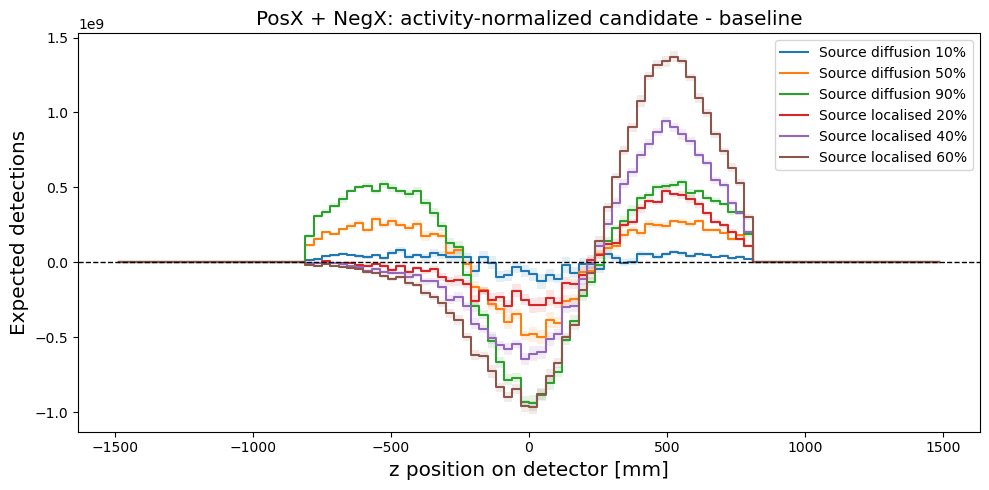

In [ ]:
activity_profile_views = {
    'PosY': ['physPhotonDetectorPosY'],
    'NegY': ['physPhotonDetectorNegY'],
    'PosX + NegX': x_panels,
}

activity_profile_results = {}
activity_summary_rows = []
for key in candidate_keys_available:
    activity_profile_results[key] = {}
    for view_name, panels in activity_profile_views.items():
        result = activity_residual(cases, key, panels, time_limit_s=default_profile_time_limit_s)
        activity_profile_results[key][view_name] = result
        activity_summary_rows.append({
            'case': key,
            'label': case_labels[key],
            'view': view_name,
            'candidate_reps': len(cases[key]),
            'baseline_reps': len(cases['baseline']),
            'time_limit_s': default_profile_time_limit_s,
            'max_abs_expected_residual': np.nanmax(np.abs(result['residual'])) if result['residual'].size else np.nan,
            'strongest_z_mm': z_centers[np.nanargmax(np.abs(result['residual']))] if result['residual'].size else np.nan,
            'integrated_expected_residual': np.nansum(result['residual']),
            'max_abs_zscore': np.nanmax(np.abs(result['zscore'])) if result['zscore'].size else np.nan,
        })

activity_profile_summary_df = pd.DataFrame(activity_summary_rows)
display(activity_profile_summary_df)

for view_name, panels in activity_profile_views.items():
    fig, ax = plt.subplots(figsize=(10, 5))
    for key in candidate_keys_available:
        result = activity_profile_results[key][view_name]
        residual = result['residual']
        sigma = result['sigma']
        ax.step(z_centers, residual, where='mid', label=case_labels[key])
        ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', alpha=0.12)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{view_name}: activity-normalized candidate - baseline', fontsize='x-large')
    ax.set_xlabel('z position on detector [mm]', fontsize='x-large')
    ax.set_ylabel('Expected detections', fontsize='x-large')
    ax.legend(fontsize=10)
    plt.tight_layout()
    save_figure(fig, f'activity_scaled_profile_{view_name}')
    plt.show()


## Activity-normalized cumulative time cuts

For each cumulative cut `time_s <= T`, the simulation timing selects detections up to that time and the surviving simulated counts are scaled to the configured initial Rn-222 activity. The thresholds focus on early detectability: `15 min`, `30 min`, `1 h`, `2 h`, `6 h`, and `1 d`.


,case,label,view,time_label,time_s,candidate_reps,baseline_reps,max_abs_expected_residual,strongest_z_mm,integrated_expected_residual,integrated_abs_expected_residual,max_abs_zscore
0,diff10,Source diffusion 10%,PosY,15 min,900,10,10,6.396087e+05,255.0,1.947710e+06,4.467157e+06,1.000000
1,diff10,Source diffusion 10%,PosY,30 min,1800,10,10,1.273530e+06,-225.0,-1.742429e+06,1.332020e+07,1.499999
2,diff10,Source diffusion 10%,PosY,1 h,3600,10,10,4.459868e+06,-345.0,-1.699221e+07,5.447350e+07,2.618569
3,diff10,Source diffusion 10%,PosY,2 h,7200,10,10,1.257680e+07,-105.0,-5.772972e+07,1.219073e+08,2.904087
4,diff10,Source diffusion 10%,PosY,6 h,21600,10,10,2.088470e+07,-15.0,-6.278307e+07,2.170048e+08,2.613812
...,...,...,...,...,...,...,...,...,...,...,...,...
121,loc60,Source localised 60%,PosX + NegX,1 h,3600,10,10,5.048593e+06,15.0,-1.365291e+06,7.145545e+07,2.451713
122,loc60,Source localised 60%,PosX + NegX,2 h,7200,10,10,1.291359e+07,405.0,-4.648813e+06,2.652503e+08,4.717261
123,loc60,Source localised 60%,PosX + NegX,6 h,21600,10,10,6.235952e+07,525.0,1.782864e+08,1.096706e+09,11.383463
124,loc60,Source localised 60%,PosX + NegX,1 d,86400,10,10,2.324601e+08,525.0,7.355439e+08,4.583673e+09,29.825323


Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_diff10.png


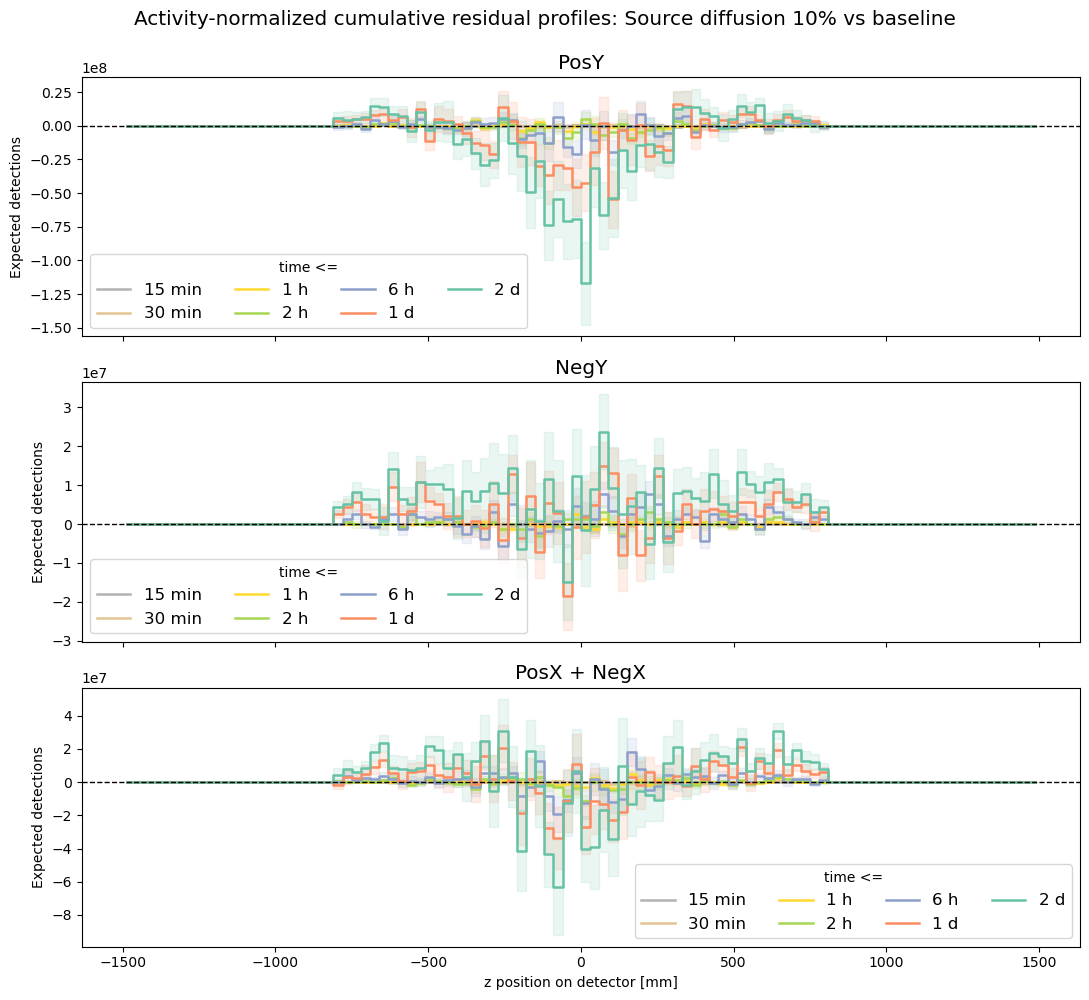

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_diff50.png


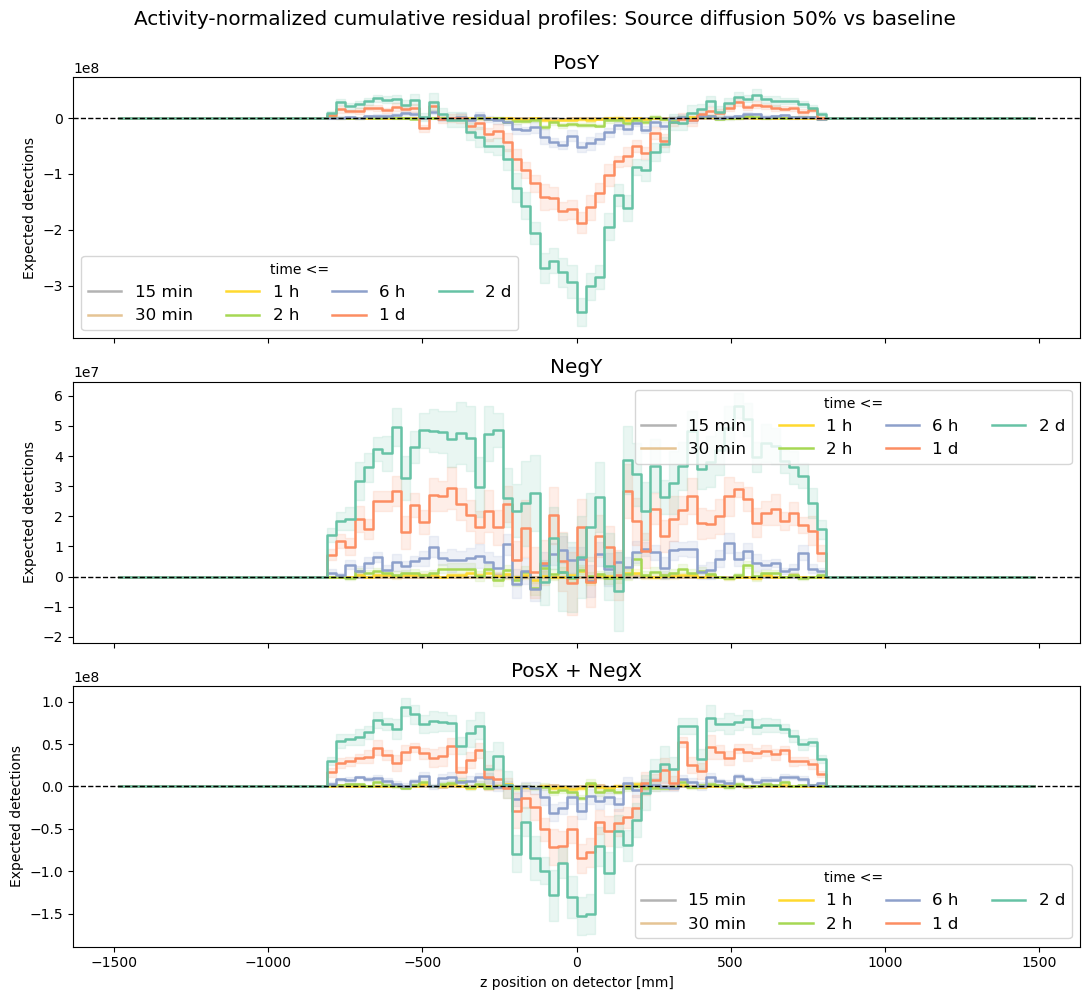

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_diff90.png


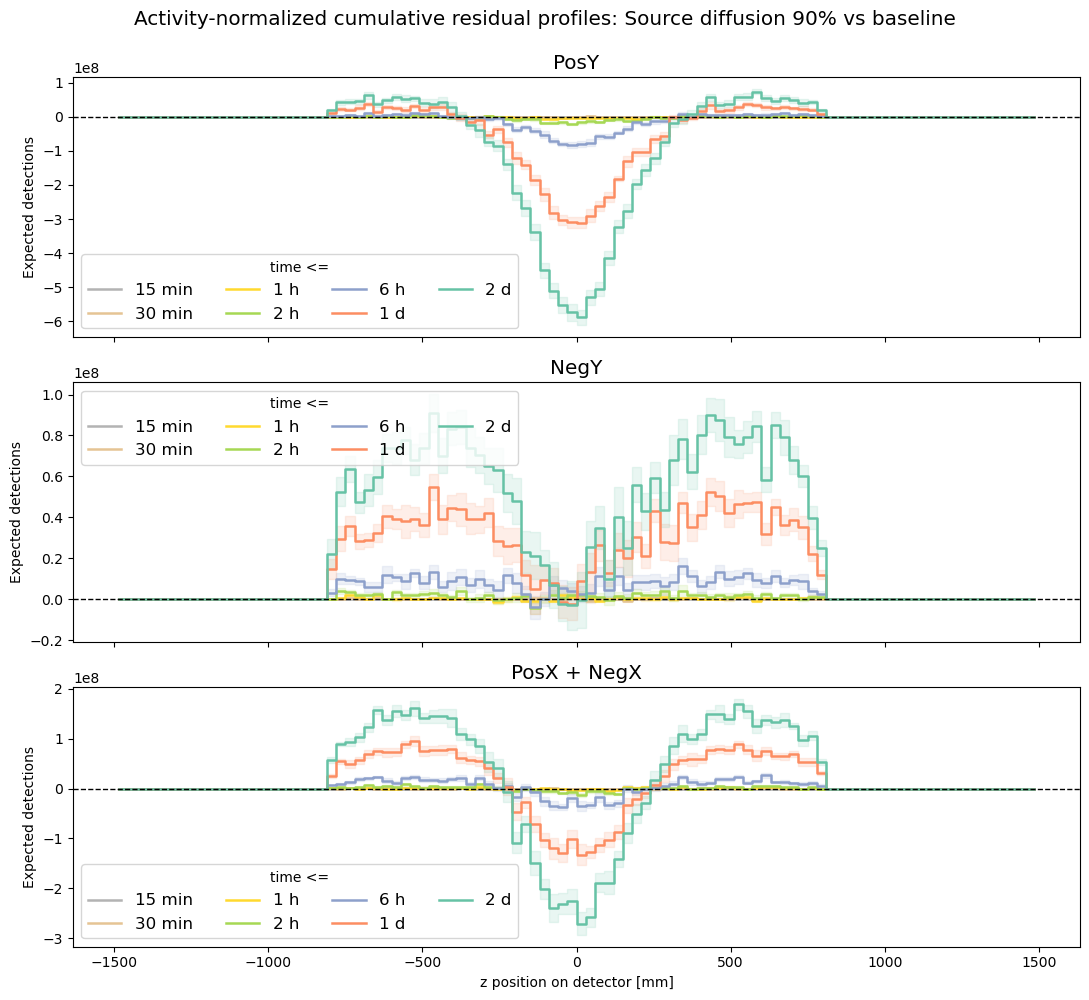

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_loc20.png


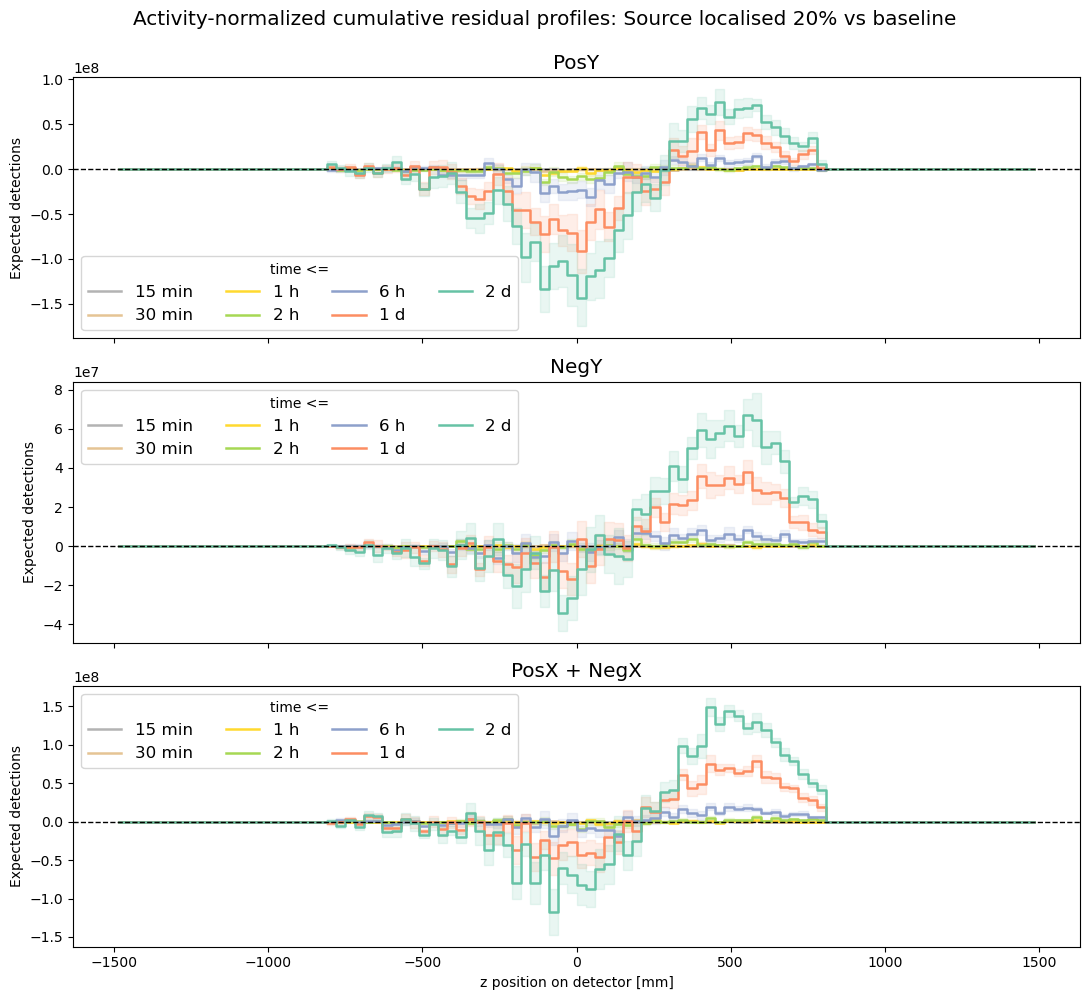

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_loc40.png


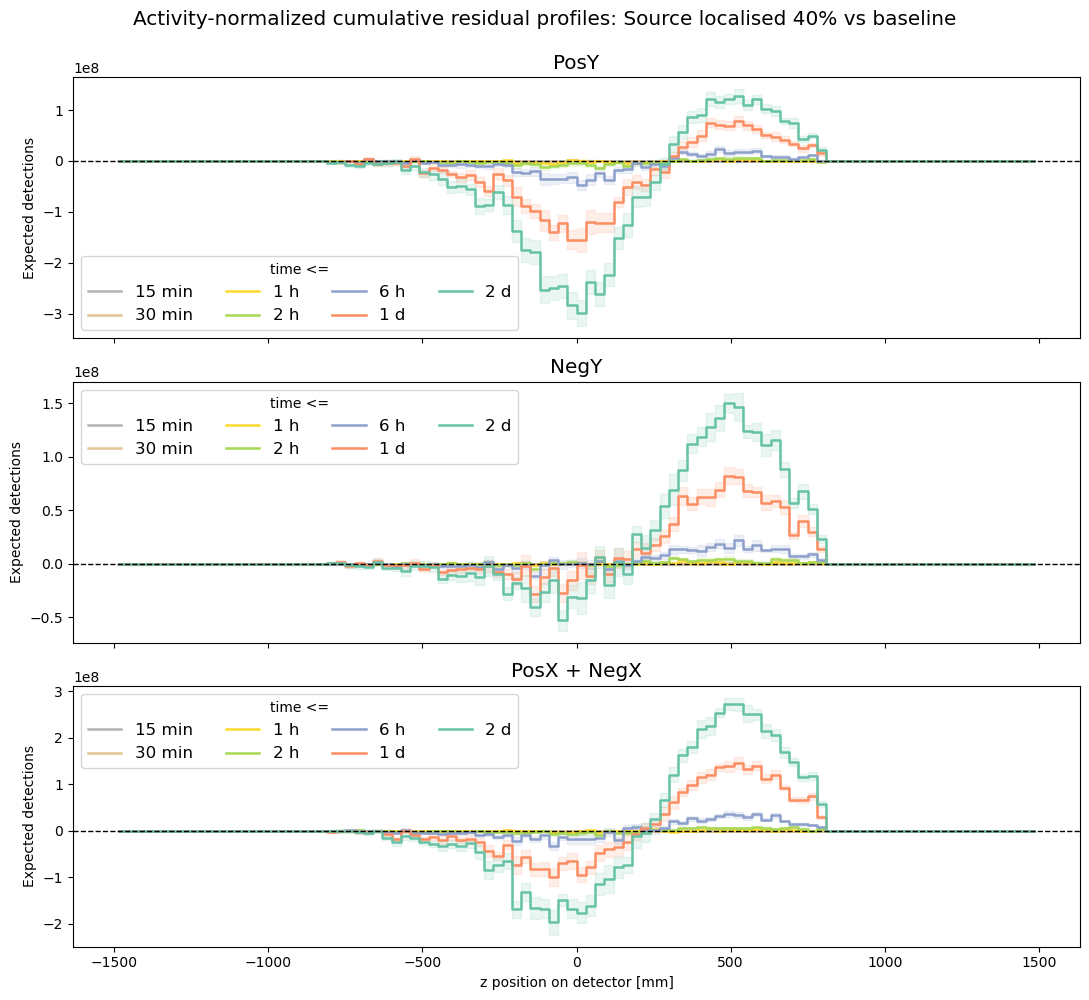

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_loc60.png


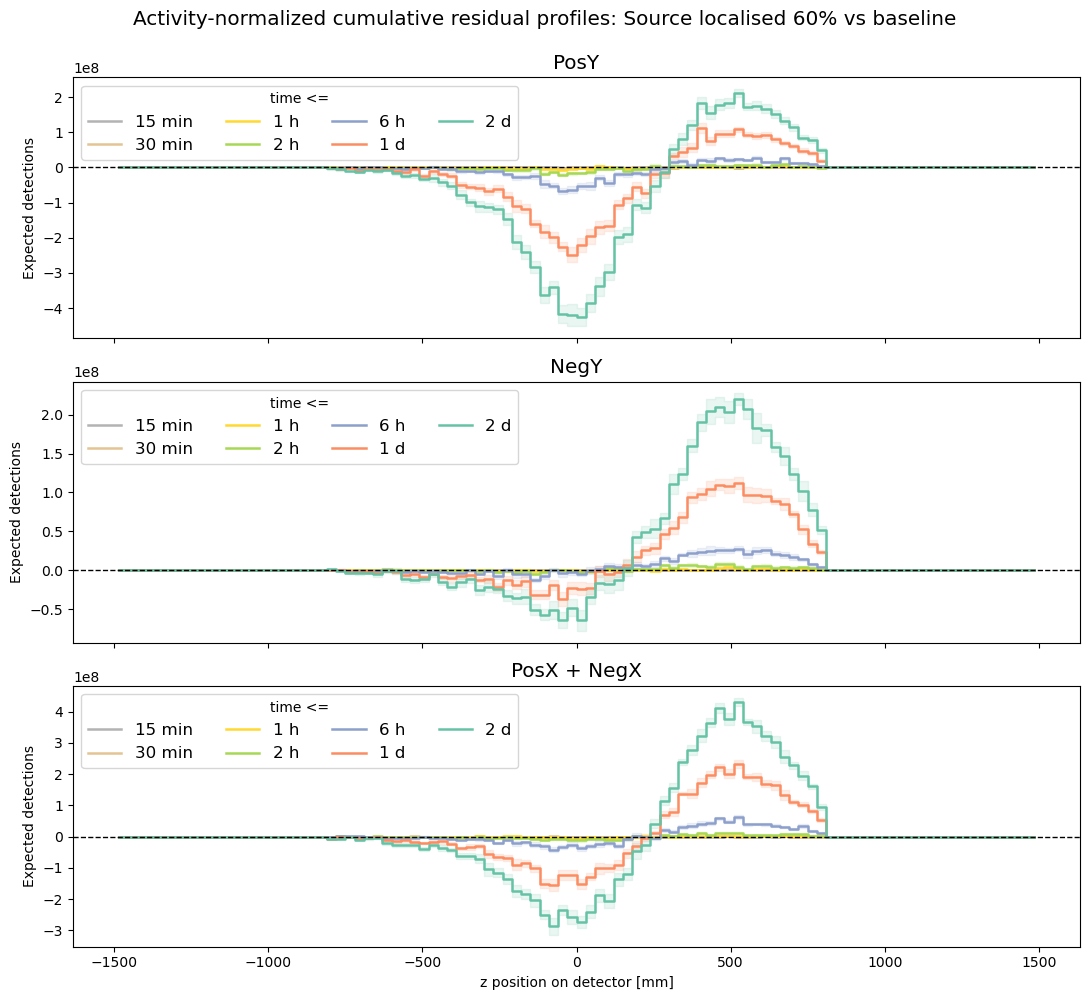

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_posx_negx_diff10.png


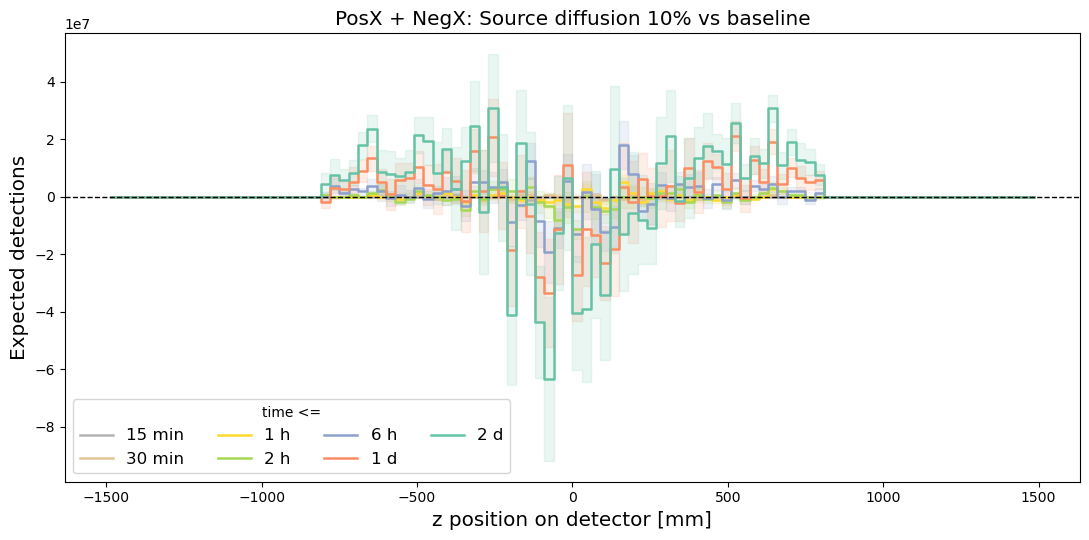

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_posx_negx_diff50.png


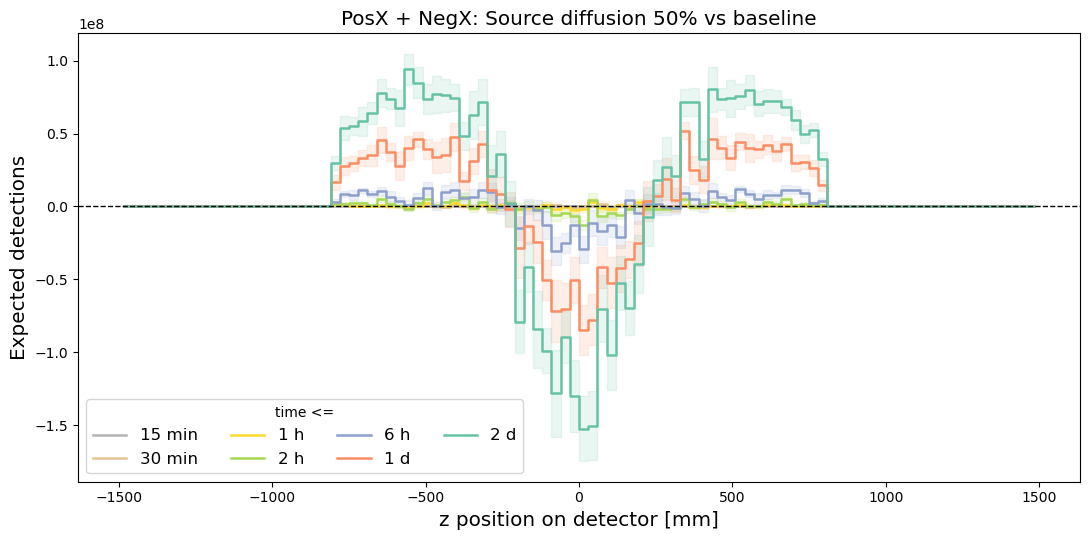

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_posx_negx_diff90.png


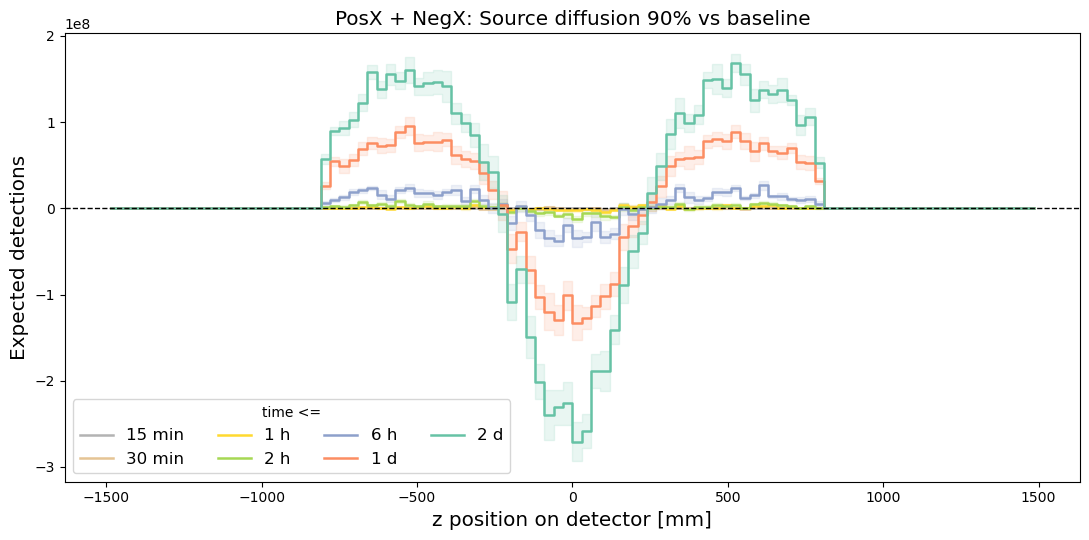

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_posx_negx_loc20.png


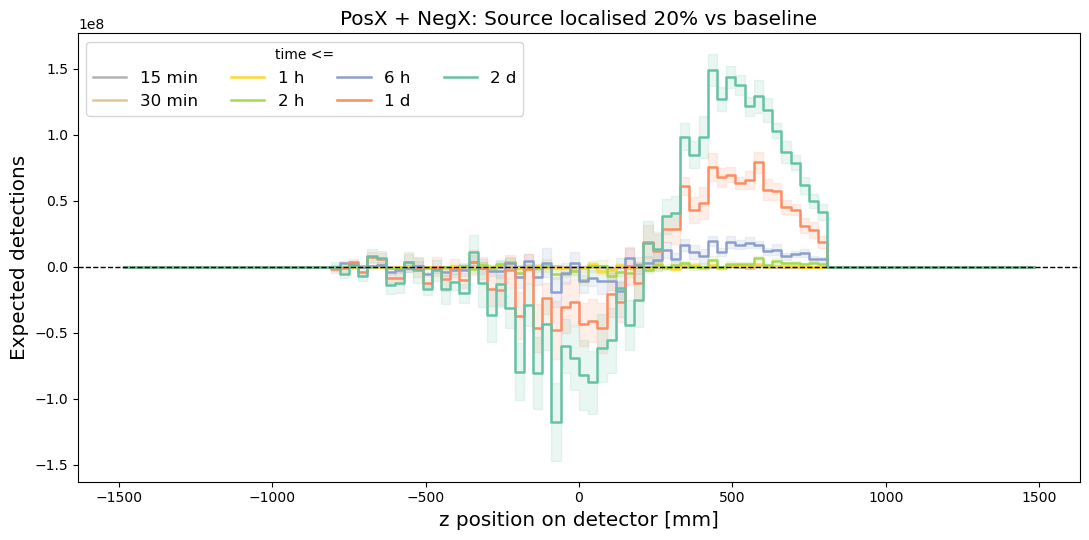

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_posx_negx_loc40.png


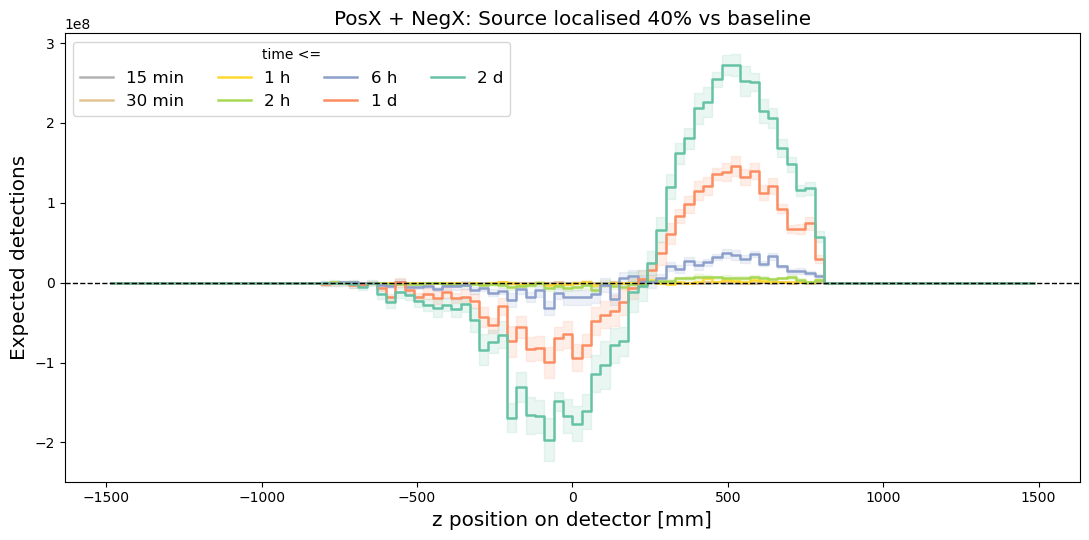

Saved figure: figures/Detector_performance_analysis_Rn222_activity_normalized/activity_time_residual_profiles_posx_negx_loc60.png


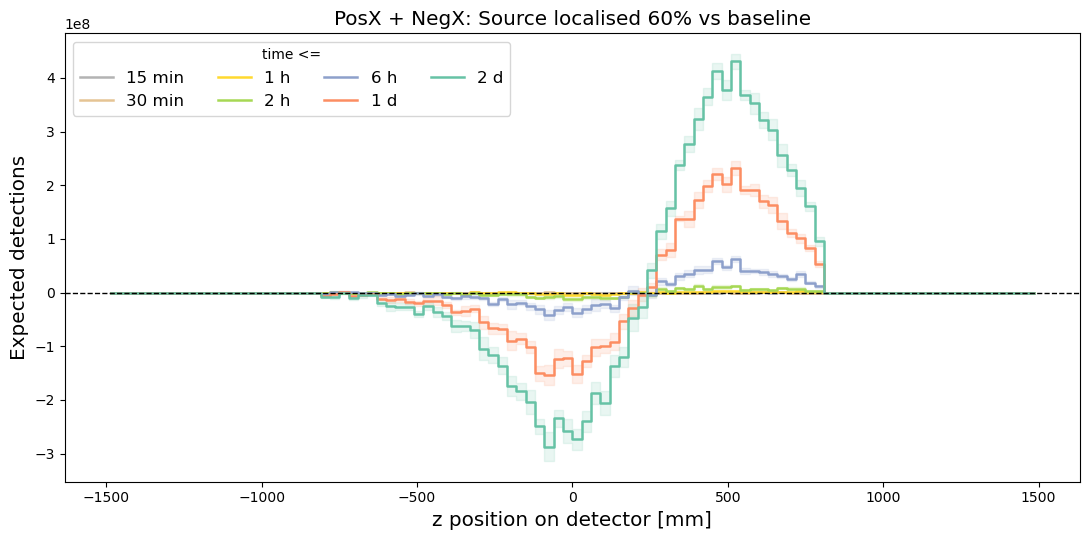

In [104]:
activity_time_results = {}
activity_time_rows = []
for key in candidate_keys_available:
    activity_time_results[key] = {}
    for view_name, panels in activity_profile_views.items():
        activity_time_results[key][view_name] = {}
        for time_label, time_limit_s in time_thresholds:
            result = activity_residual(cases, key, panels, time_limit_s=time_limit_s)
            activity_time_results[key][view_name][time_label] = {'time_s': time_limit_s, **result}
            activity_time_rows.append({
                'case': key,
                'label': case_labels[key],
                'view': view_name,
                'time_label': time_label,
                'time_s': time_limit_s,
                'candidate_reps': len(cases[key]),
                'baseline_reps': len(cases['baseline']),
                'max_abs_expected_residual': np.nanmax(np.abs(result['residual'])) if result['residual'].size else np.nan,
                'strongest_z_mm': z_centers[np.nanargmax(np.abs(result['residual']))] if result['residual'].size else np.nan,
                'integrated_expected_residual': np.nansum(result['residual']),
                'integrated_abs_expected_residual': np.nansum(np.abs(result['residual'])),
                'max_abs_zscore': np.nanmax(np.abs(result['zscore'])) if result['zscore'].size else np.nan,
            })

activity_time_summary_df = pd.DataFrame(activity_time_rows)
display(activity_time_summary_df)

#dark_time_palette = ['#111111', '#00429d', '#006d5b', '#8c6d1f', '#b23a1f', '#7f1d4e', '#4d4d4d']
time_colors = dict(zip([label for label, _ in time_thresholds], plt.cm.Set2_r(np.linspace(0.05, 0.95, len(time_thresholds)))))
#time_colors = dict(zip([label for label, _ in time_thresholds], dark_time_palette[:len(time_thresholds)]))
for key in candidate_keys_available:
    fig, axes = plt.subplots(len(activity_profile_views), 1, figsize=(11, 10), sharex=True)
    for ax, (view_name, panels) in zip(axes, activity_profile_views.items()):
        for time_label, _ in time_thresholds:
            result = activity_time_results[key][view_name][time_label]
            residual = result['residual']
            sigma = result['sigma']
            color = time_colors[time_label]
            ax.step(z_centers, residual, where='mid', color=color, linewidth=1.8, label=time_label)
            ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', color=color, alpha=0.14)
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_title(view_name, fontsize='x-large')
        ax.set_ylabel('Expected detections')
        ax.legend(title='time <=', fontsize='large', ncols=4)
    axes[-1].set_xlabel('z position on detector [mm]')
    fig.suptitle(f'Activity-normalized cumulative residual profiles: {case_labels[key]} vs baseline', y=0.995, fontsize='x-large')
    plt.tight_layout()
    save_figure(fig, f'activity_time_residual_profiles_{key}')
    plt.show()


# Separate single-panel version: combined PosX + NegX cumulative residual profiles.
for key in candidate_keys_available:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    view_name = 'PosX + NegX'
    for time_label, _ in time_thresholds:
        result = activity_time_results[key][view_name][time_label]
        residual = result['residual']
        sigma = result['sigma']
        color = time_colors[time_label]
        ax.step(z_centers, residual, where='mid', color=color, linewidth=1.8, label=time_label)
        ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', color=color, alpha=0.14)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'PosX + NegX: {case_labels[key]} vs baseline', fontsize='x-large')
    ax.set_xlabel('z position on detector [mm]', fontsize='x-large')
    ax.set_ylabel('Expected detections', fontsize='x-large')
    ax.legend(title='time <=', fontsize='large', ncols=4)
    plt.tight_layout()
    save_figure(fig, f'activity_time_residual_profiles_posx_negx_{key}')
    plt.show()

# if not activity_time_summary_df.empty:
#     fig, axes = plt.subplots(len(activity_profile_views), 1, figsize=(10, 9), sharex=True)
#     for ax, view_name in zip(axes, activity_profile_views):
#         view_df = activity_time_summary_df[activity_time_summary_df['view'] == view_name]
#         for key in candidate_keys_available:
#             case_df = view_df[view_df['case'] == key].sort_values('time_s')
#             ax.plot(case_df['time_s'], case_df['integrated_expected_residual'], marker='o', linewidth=1.8, label=case_labels[key])
#         ax.axhline(0, color='black', linestyle='--', linewidth=1)
#         set_exact_time_ticks(ax)
#         ax.set_ylabel('Expected detections', fontsize='x-large')
#         ax.set_title(view_name)
#         ax.grid(alpha=0.25)
#         ax.legend(fontsize='large')
#     axes[-1].set_xlabel('cumulative time cut')
#     fig.suptitle('Activity-normalized integrated residual vs time cut', y=0.995, fontsize='x-large')
#     plt.tight_layout()
#     save_figure(fig, 'activity_integrated_residual_vs_time')
#     plt.show()


# # Zoomed early-time views: focus on whether anything is visible up to 2 hours.
# early_time_thresholds = [(label, seconds) for label, seconds in time_thresholds if seconds <= 2 * 3600]
# early_time_ylim = (-1e7, 1e7)

# early_time_colors = dict(zip([label for label, _ in early_time_thresholds], plt.cm.plasma(np.linspace(0.10, 0.90, len(early_time_thresholds)))))
# for key in candidate_keys_available:
#     fig, axes = plt.subplots(len(activity_profile_views), 1, figsize=(11, 10), sharex=True)
#     for ax, (view_name, panels) in zip(axes, activity_profile_views.items()):
#         for time_label, _ in early_time_thresholds:
#             result = activity_time_results[key][view_name][time_label]
#             residual = result['residual']
#             sigma = result['sigma']
#             color = early_time_colors[time_label]
#             ax.step(z_centers, residual, where='mid', color=color, linewidth=1.8, label=time_label)
#             ax.fill_between(z_centers, residual - sigma, residual + sigma, step='mid', color=color, alpha=0.14)
#         ax.axhline(0, color='black', linestyle='--', linewidth=1)
#         ax.set_ylim(*early_time_ylim)
#         ax.set_title(view_name, fontsize='x-large')
#         ax.set_ylabel('Expected detections', fontsize='x-large')
#         ax.legend(title='time <=', fontsize='large', ncols=4)
#     axes[-1].set_xlabel('z position on detector [mm]', fontsize='x-large')
#     fig.suptitle(f'Early-time zoomed residual profiles: {case_labels[key]} vs baseline', y=0.995, fontsize='x-large')
#     plt.tight_layout()
#     save_figure(fig, f'activity_time_residual_profiles_early_zoom_{key}')
#     plt.show()

# if not activity_time_summary_df.empty:
#     fig, axes = plt.subplots(len(activity_profile_views), 1, figsize=(10, 9), sharex=True)
#     early_labels = [label for label, _ in early_time_thresholds]
#     for ax, view_name in zip(axes, activity_profile_views):
#         view_df = activity_time_summary_df[
#             (activity_time_summary_df['view'] == view_name)
#             & (activity_time_summary_df['time_label'].isin(early_labels))
#         ]
#         for key in candidate_keys_available:
#             case_df = view_df[view_df['case'] == key].sort_values('time_s')
#             ax.plot(case_df['time_s'], case_df['integrated_expected_residual'], marker='o', linewidth=1.8, label=case_labels[key])
#         ax.axhline(0, color='black', linestyle='--', linewidth=1)
#         ax.set_ylim(*early_time_ylim)
#         set_exact_time_ticks(ax, early_time_thresholds)
#         ax.set_ylabel('Expected detections', fontsize='x-large')
#         ax.set_title(view_name, fontsize='x-large')
#         ax.grid(alpha=0.25)
#         ax.legend(fontsize='large')
#     axes[-1].set_xlabel('cumulative time cut', fontsize='x-large')
#     fig.suptitle('Early-time zoomed integrated residual vs time cut', y=0.995, fontsize='x-large')
#     plt.tight_layout()
#     save_figure(fig, 'activity_integrated_residual_vs_time_early_zoom')
#     plt.show()


# # All-positive signal diagnostic: integrate abs(candidate - baseline) across z bins.
# # This avoids cancellation between positive and negative residual regions.
# if not activity_time_summary_df.empty:
#     fig, axes = plt.subplots(len(activity_profile_views), 1, figsize=(10, 9), sharex=True)
#     for ax, view_name in zip(axes, activity_profile_views):
#         view_df = activity_time_summary_df[activity_time_summary_df['view'] == view_name]
#         for key in candidate_keys_available:
#             case_df = view_df[view_df['case'] == key].sort_values('time_s')
#             ax.plot(case_df['time_s'], case_df['integrated_abs_expected_residual'], marker='o', linewidth=1.8, label=case_labels[key])
#         set_exact_time_ticks(ax)
#         ax.set_ylabel('Expected detections', fontsize='x-large')
#         ax.set_title(view_name, fontsize='x-large')
#         ax.grid(alpha=0.25)
#         ax.legend(fontsize='large')
#     axes[-1].set_xlabel('cumulative time cut', fontsize='x-large')
#     fig.suptitle('Integrated absolute residual vs time cut', y=0.995, fontsize='x-large')
#     plt.tight_layout()
#     save_figure(fig, 'activity_integrated_abs_residual_vs_time')
#     plt.show()

# if not activity_time_summary_df.empty:
#     fig, axes = plt.subplots(len(activity_profile_views), 1, figsize=(10, 9), sharex=True)
#     early_labels = [label for label, _ in early_time_thresholds]
#     for ax, view_name in zip(axes, activity_profile_views):
#         view_df = activity_time_summary_df[
#             (activity_time_summary_df['view'] == view_name)
#             & (activity_time_summary_df['time_label'].isin(early_labels))
#         ]
#         for key in candidate_keys_available:
#             case_df = view_df[view_df['case'] == key].sort_values('time_s')
#             ax.plot(case_df['time_s'], case_df['integrated_abs_expected_residual'], marker='o', linewidth=1.8, label=case_labels[key])
#         set_exact_time_ticks(ax, early_time_thresholds)
#         ax.set_ylabel('Expected detections', fontsize='x-large')
#         ax.set_title(view_name, fontsize='x-large')
#         ax.grid(alpha=0.25)
#         ax.legend(fontsize='large')
#     axes[-1].set_xlabel('cumulative time cut', fontsize='x-large')
#     fig.suptitle('Early-time integrated absolute residual vs time cut', y=0.995, fontsize='x-large')
#     plt.tight_layout()
#     save_figure(fig, 'activity_integrated_abs_residual_vs_time_early')
#     plt.show()


## Far-side leakage / diffusion region

The localized source is centred at `z = +500 mm`. This section defines a low-signal region on the opposite side of the phantom, `-750 <= z < -500 mm`, using the combined `PosX + NegX` panels. An excess above the baseline in this region is treated as a leakage/diffusion indicator. The ROI boundaries are configurable below.


In [ ]:
# Far-side leakage/diffusion ROI analysis
# The ROI is deliberately opposite the localized source at z = +500 mm.

leakage_roi_z_mm = (-750.0, -500.0)
leakage_panels = x_panels
leakage_view_label = 'PosX + NegX'
leakage_time_limit_s = default_profile_time_limit_s

leakage_case_order = ['baseline'] + candidate_keys_available
leakage_case_palette = {
    'baseline': '#4d4d4d',
    'diff10': '#2c7fb8',
    'diff50': '#225ea8',
    'diff90': '#253494',
    'loc20': '#fdae6b',
    'loc40': '#e6550d',
    'loc60': '#a63603',
}

def activity_scaled_roi_counts(repetitions, panels, z_roi_mm, time_limit_s=None):
    """Return activity-scaled ROI counts for every repetition."""
    z_min, z_max = z_roi_mm
    expected_counts = []
    roi_fractions = []
    raw_counts = []
    for rep in repetitions:
        selected = select_entries(rep, panels, time_limit_s=time_limit_s)
        roi = selected[(selected['z_mm'] >= z_min) & (selected['z_mm'] < z_max)]
        raw_roi_count = float(len(roi))
        raw_total_count = float(len(selected))
        scale = rn222_initial_atoms / rep['n_events']
        raw_counts.append(raw_roi_count)
        expected_counts.append(raw_roi_count * scale)
        roi_fractions.append(raw_roi_count / raw_total_count if raw_total_count > 0 else np.nan)
    return np.asarray(expected_counts), np.asarray(roi_fractions), np.asarray(raw_counts)

def mean_sem(values, poisson_counts=None, scale=None):
    """Return mean and SEM; use a Poisson fallback when only one repetition exists."""
    values = np.asarray(values, dtype=float)
    mean = np.nanmean(values)
    finite = values[np.isfinite(values)]
    if len(finite) > 1:
        sem = np.nanstd(values, ddof=1) / np.sqrt(len(finite))
    elif poisson_counts is not None and scale is not None:
        sem = np.sqrt(poisson_counts[0]) * scale
    else:
        sem = np.nan
    return mean, sem

def leakage_case_statistics(case_key, time_limit_s):
    """Calculate expected ROI counts and ROI fraction for one case and time cut."""
    repetitions = cases[case_key]
    expected, fractions, raw = activity_scaled_roi_counts(
        repetitions,
        leakage_panels,
        leakage_roi_z_mm,
        time_limit_s=time_limit_s,
    )
    events = np.asarray([rep['n_events'] for rep in repetitions], dtype=float)
    mean_expected, sem_expected = mean_sem(
        expected,
        poisson_counts=raw,
        scale=rn222_initial_atoms / events[0],
    )
    mean_fraction, sem_fraction = mean_sem(fractions)
    return {
        'expected_by_rep': expected,
        'fraction_by_rep': fractions,
        'mean_expected': mean_expected,
        'sem_expected': sem_expected,
        'mean_fraction': mean_fraction,
        'sem_fraction': sem_fraction,
    }

baseline_leakage = leakage_case_statistics('baseline', leakage_time_limit_s)
leakage_rows = []
leakage_results = {'baseline': baseline_leakage}

for key in leakage_case_order:
    result = baseline_leakage if key == 'baseline' else leakage_case_statistics(key, leakage_time_limit_s)
    leakage_results[key] = result
    excess = result['mean_expected'] - baseline_leakage['mean_expected']
    excess_sigma = np.sqrt(result['sem_expected'] ** 2 + baseline_leakage['sem_expected'] ** 2)
    excess_zscore = excess / excess_sigma if excess_sigma > 0 else np.nan
    baseline_count = baseline_leakage['mean_expected']
    leakage_rows.append({
        'case': key,
        'label': case_labels.get(key, 'Baseline'),
        'roi_z_min_mm': leakage_roi_z_mm[0],
        'roi_z_max_mm': leakage_roi_z_mm[1],
        'time_limit_s': leakage_time_limit_s,
        'repetitions': len(cases[key]),
        'expected_roi_detections': result['mean_expected'],
        'expected_roi_sem': result['sem_expected'],
        'excess_vs_baseline': excess,
        'excess_sigma': excess_sigma,
        'excess_zscore': excess_zscore,
        'roi_to_baseline_ratio': result['mean_expected'] / baseline_count if baseline_count > 0 else np.nan,
        'roi_fraction_of_panel_hits': result['mean_fraction'],
        'roi_fraction_sem': result['sem_fraction'],
        'roi_fraction_excess': result['mean_fraction'] - baseline_leakage['mean_fraction'],
    })

leakage_summary_df = pd.DataFrame(leakage_rows)
display(leakage_summary_df)

# Absolute expected detections in the far-side ROI.
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(leakage_case_order))
absolute_values = [leakage_results[key]['mean_expected'] for key in leakage_case_order]
absolute_errors = [leakage_results[key]['sem_expected'] for key in leakage_case_order]
colors = [leakage_case_palette.get(key, '#666666') for key in leakage_case_order]
ax.bar(x, absolute_values, yerr=absolute_errors, capsize=4, color=colors, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels([case_labels.get(key, 'Baseline') for key in leakage_case_order], rotation=25, ha='right')
ax.set_ylabel('Expected detections', fontsize='x-large')
ax.set_title(f'Far-side ROI: {leakage_roi_z_mm[0]:g} to {leakage_roi_z_mm[1]:g} mm', fontsize='x-large')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
save_figure(fig, 'activity_far_side_roi_expected_detections')
plt.show()

# Candidate-minus-baseline excess in the far-side ROI.
plot_keys = candidate_keys_available
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(plot_keys))
excess_values = [leakage_summary_df.loc[leakage_summary_df['case'] == key, 'excess_vs_baseline'].iloc[0] for key in plot_keys]
excess_errors = [leakage_summary_df.loc[leakage_summary_df['case'] == key, 'excess_sigma'].iloc[0] for key in plot_keys]
colors = [leakage_case_palette.get(key, '#666666') for key in plot_keys]
ax.bar(x, excess_values, yerr=excess_errors, capsize=4, color=colors, alpha=0.9)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([case_labels[key] for key in plot_keys], rotation=25, ha='right')
ax.set_ylabel('Expected detections', fontsize='x-large')
ax.set_title('Far-side ROI excess above baseline', fontsize='x-large')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
save_figure(fig, 'activity_far_side_roi_excess_vs_baseline')
plt.show()

# Significance of the integrated far-side excess.
fig, ax = plt.subplots(figsize=(11, 5.5))
z_values = [leakage_summary_df.loc[leakage_summary_df['case'] == key, 'excess_zscore'].iloc[0] for key in plot_keys]
ax.bar(x, z_values, color=colors, alpha=0.9)
ax.axhline(0, color='black', linewidth=1)
ax.axhline(3, color='grey', linestyle=':', linewidth=1)
ax.axhline(-3, color='grey', linestyle=':', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([case_labels[key] for key in plot_keys], rotation=25, ha='right')
ax.set_ylabel('Z-score', fontsize='x-large')
ax.set_title('Far-side ROI excess significance', fontsize='x-large')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
save_figure(fig, 'activity_far_side_roi_excess_zscore')
plt.show()

# Cumulative time evolution of the far-side candidate-minus-baseline excess.
leakage_time_rows = []
for time_label, time_limit_s in time_thresholds:
    baseline_at_time = leakage_case_statistics('baseline', time_limit_s)
    for key in candidate_keys_available:
        candidate_at_time = leakage_case_statistics(key, time_limit_s)
        excess = candidate_at_time['mean_expected'] - baseline_at_time['mean_expected']
        sigma = np.sqrt(candidate_at_time['sem_expected'] ** 2 + baseline_at_time['sem_expected'] ** 2)
        leakage_time_rows.append({
            'case': key,
            'label': case_labels[key],
            'time_label': time_label,
            'time_s': time_limit_s,
            'expected_roi_excess': excess,
            'excess_sigma': sigma,
            'excess_zscore': excess / sigma if sigma > 0 else np.nan,
        })

leakage_time_summary_df = pd.DataFrame(leakage_time_rows)
display(leakage_time_summary_df)

fig, ax = plt.subplots(figsize=(11, 5.5))
for key in candidate_keys_available:
    case_df = leakage_time_summary_df[leakage_time_summary_df['case'] == key].sort_values('time_s')
    ax.errorbar(
        case_df['time_s'],
        case_df['expected_roi_excess'],
        yerr=case_df['excess_sigma'],
        marker='o',
        linewidth=1.8,
        capsize=3,
        color=leakage_case_palette.get(key),
        label=case_labels[key],
    )
ax.axhline(0, color='black', linestyle='--', linewidth=1)
set_exact_time_ticks(ax)
ax.set_xlabel('Cumulative time cut', fontsize='x-large')
ax.set_ylabel('Expected detections', fontsize='x-large')
ax.set_title('Far-side ROI excess vs time', fontsize='x-large')
ax.grid(alpha=0.25)
ax.legend(fontsize='large', ncols=2)
plt.tight_layout()
save_figure(fig, 'activity_far_side_roi_excess_vs_time')
plt.show()
